##  House Price prediction - EDA 

- Exploring housing dataset and find strongest predictors for SalesPrice 


In [ ]:
# all required libs for importing and ploting data  
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import dabl as dbl

In [ ]:
#quick load data and check top 5 samples in data 
data= pd.read_csv("train.csv")
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Data Overview
- Quick loockup on the data shape and size and colums for data understanding.
- statistical discription of target (mean,minimum,maximum etc..)

In [4]:
data.shape

(1460, 81)

In [5]:
data.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [6]:
data["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

## Target Distribution 
- "SalesPrice" distribution matter before going furthur 


<Axes: xlabel='SalePrice', ylabel='Count'>

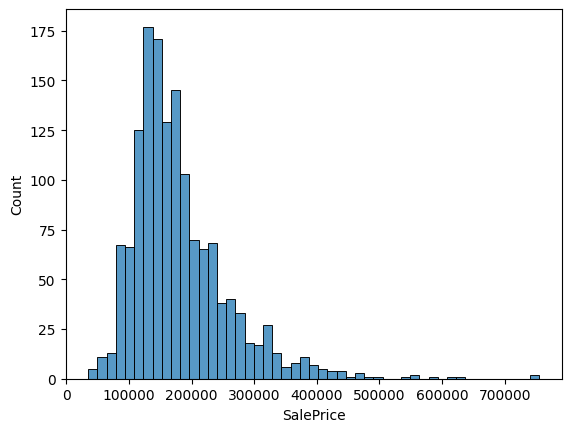

In [ ]:
# ploting distribution to see shape 
sns.histplot(data["SalePrice"])

## Auto EDA using dabl lib
- it uses all 81 features and gives a type ,distribytion,target relationship and plotting of features with respective target

In [8]:
#Returns whole details of data induvidually 
dbl.detect_types(data).T

C:\Users\Nihal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\dabl\preprocessing.py:177: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(series[:10])
C:\Users\Nihal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\dabl\preprocessing.py:177: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(series[:10])
C:\Users\Nihal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\dabl\preprocessing.py:177: UserWarning: Could not infer format, so each element will be parsed indivi

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
continuous,False,False,False,True,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
dirty_float,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
low_card_int_ordinal,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
low_card_int_categorical,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
categorical,False,False,True,False,False,False,True,True,True,False,...,False,False,True,True,False,False,True,True,True,False
date,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
free_string,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
useless,True,False,False,False,False,True,False,False,False,True,...,True,True,False,False,True,False,False,False,False,False


C:\Users\Nihal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\dabl\preprocessing.py:177: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(series[:10])
C:\Users\Nihal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\dabl\preprocessing.py:177: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(series[:10])
C:\Users\Nihal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\dabl\preprocessing.py:177: UserWarning: Could not infer format, so each element will be parsed indivi

Target looks like regression


C:\Users\Nihal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\dabl\plot\supervised.py:111: UserWarning: Showing only top 10 continuous features.
  warn("Showing only top 10 continuous features.")


Showing only top 10 of 44 categorical features


C:\Users\Nihal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\dabl\plot\supervised.py:214: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  medians = X_new.groupby(col)[target_col].median()
C:\Users\Nihal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\dabl\plot\supervised.py:214: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  medians = X_new.groupby(col)[target_col].median()
C:\Users\Nihal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0

[<Axes: title={'center': 'Target distribution'}, xlabel='SalePrice', ylabel='frequency'>,
 array([[<Axes: title={'center': 'F=8.09E-01'}, xlabel='OverallQual (jittered)', ylabel='SalePrice'>,
         <Axes: title={'center': 'F=7.30E-01'}, xlabel='GrLivArea'>,
         <Axes: title={'center': 'F=6.53E-01'}, xlabel='YearBuilt'>,
         <Axes: title={'center': 'F=6.48E-01'}, xlabel='GarageArea'>,
         <Axes: title={'center': 'F=6.01E-01'}, xlabel='TotalBsmtSF'>],
        [<Axes: title={'center': 'F=5.94E-01'}, xlabel='GarageYrBlt', ylabel='SalePrice'>,
         <Axes: title={'center': 'F=5.74E-01'}, xlabel='1stFlrSF'>,
         <Axes: title={'center': 'F=5.72E-01'}, xlabel='YearRemodAdd'>,
         <Axes: title={'center': 'F=5.31E-01'}, xlabel='TotRmsAbvGrd (jittered)'>,
         <Axes: title={'center': 'F=4.77E-01'}, xlabel='OpenPorchSF'>]],
       dtype=object),
 array([[<Axes: title={'center': 'F=5.25E-01'}, xlabel='SalePrice', ylabel='MSSubClass'>,
         <Axes: title={'cente

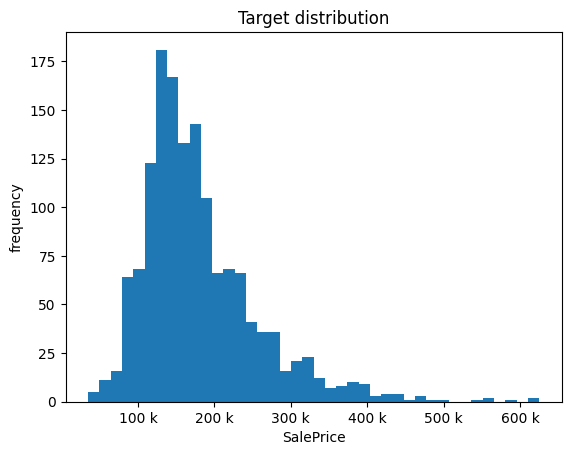

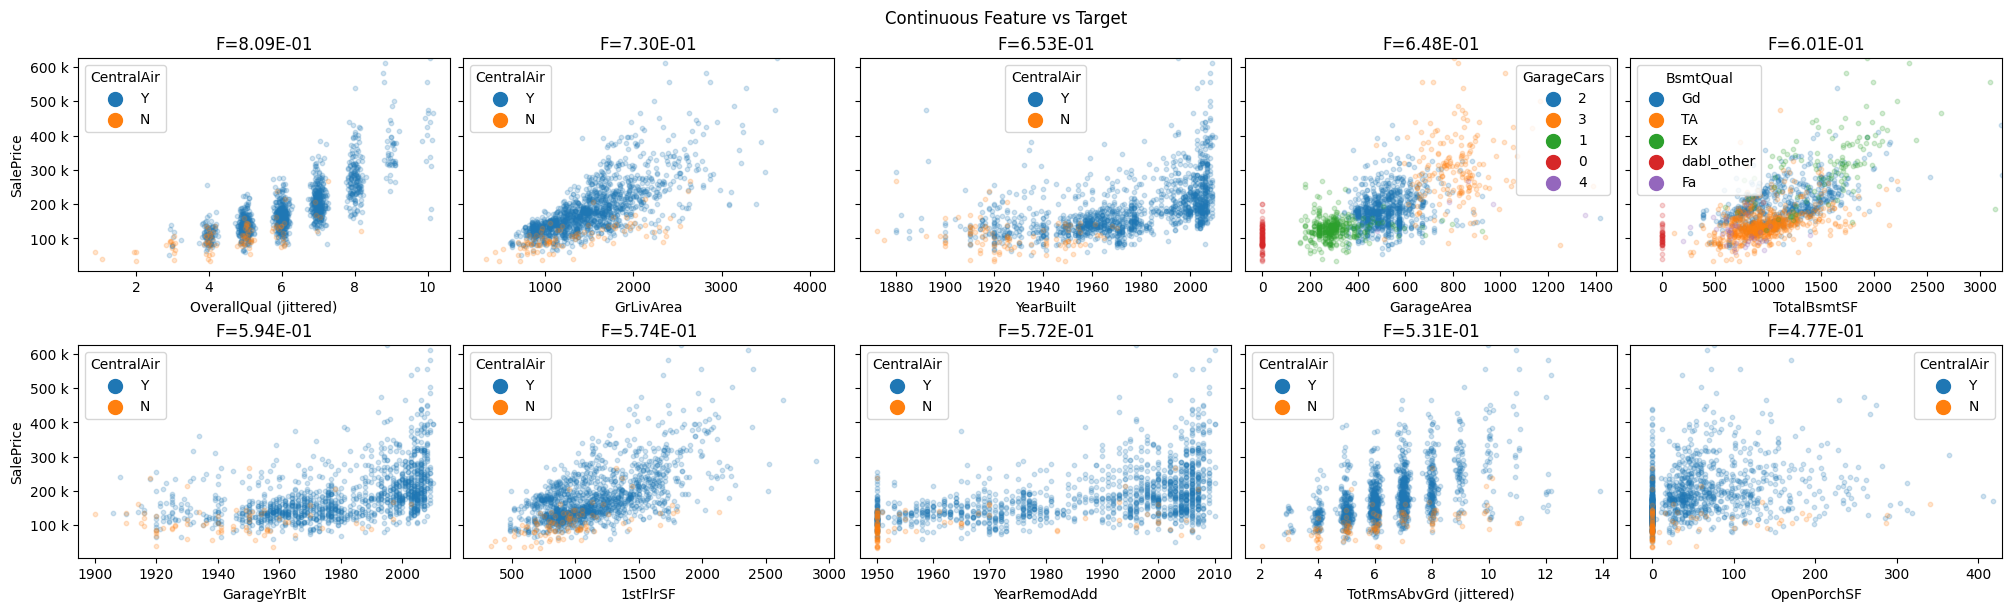

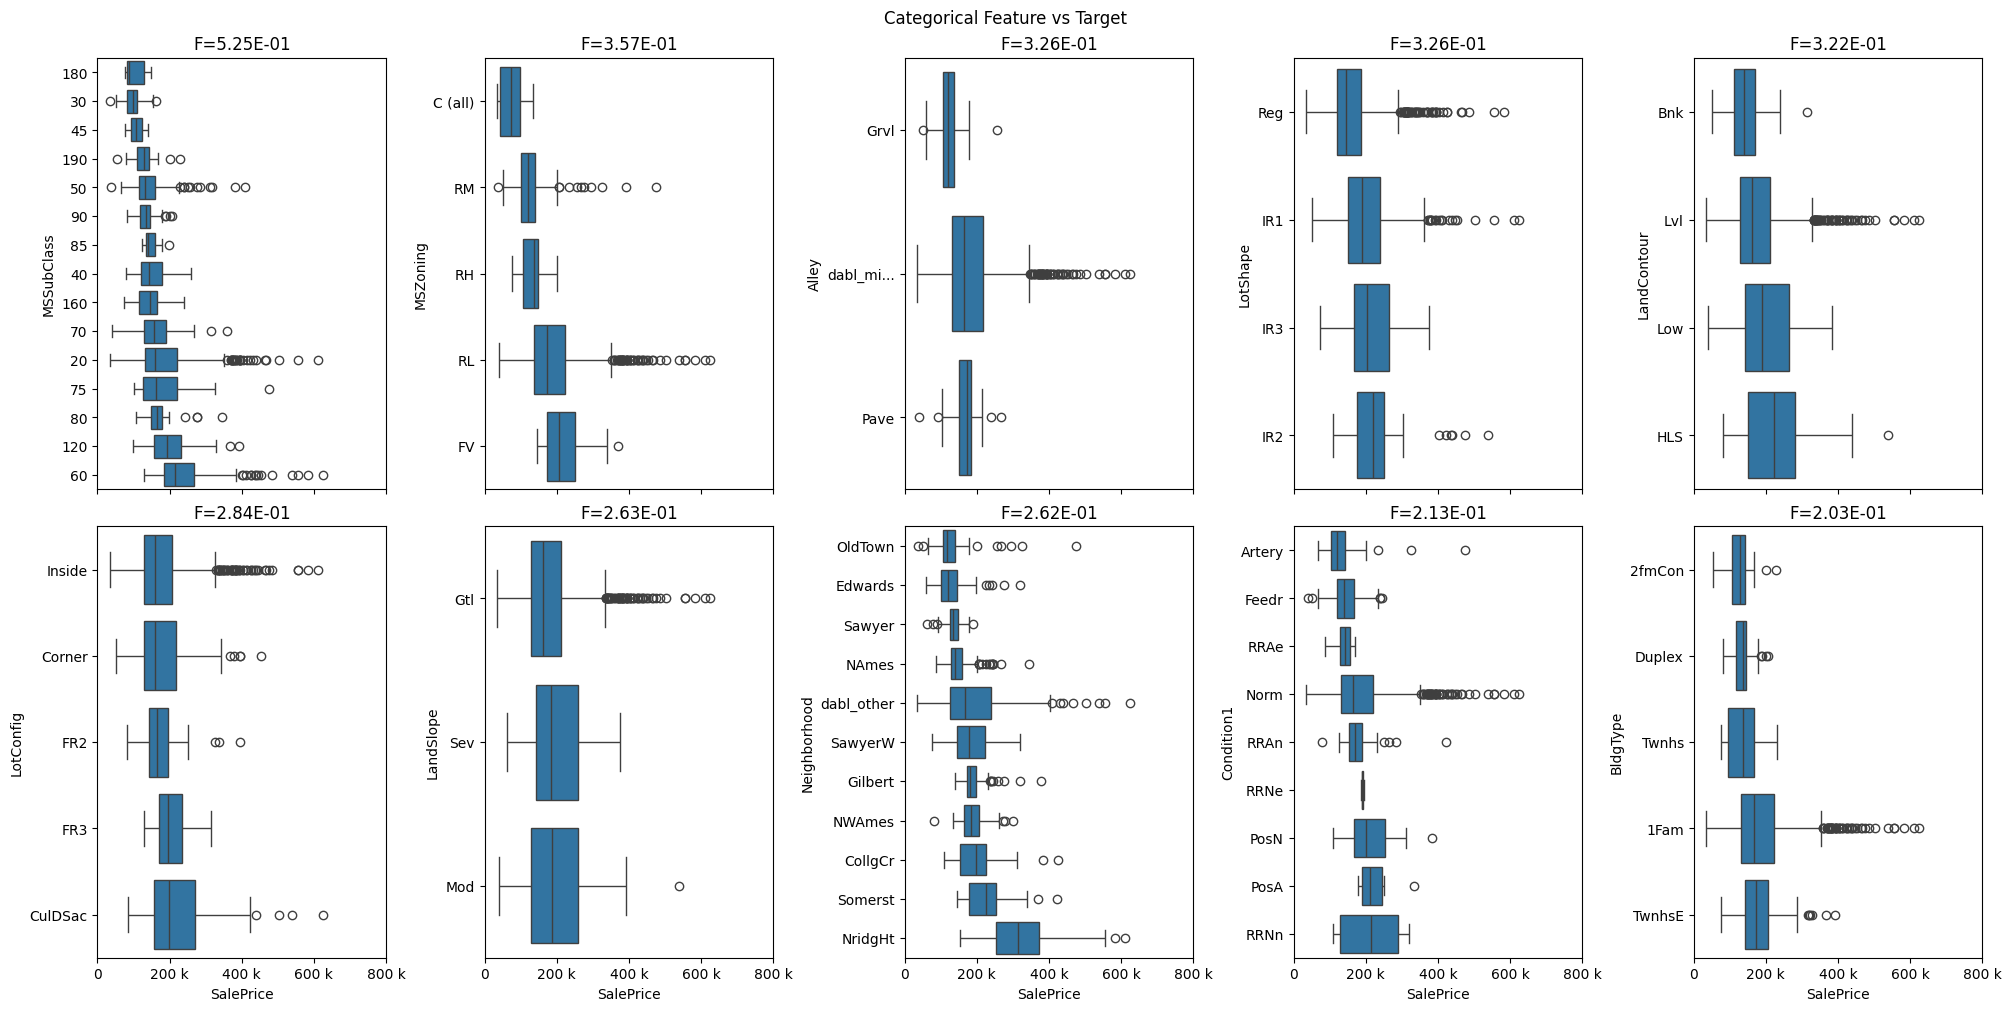

In [9]:
#Gives all plots of data which can be plot using SalesPrice as a target 
# no need to specify type of plots 
dbl.plot(data,target_col="SalePrice")

## Correlation Analysis

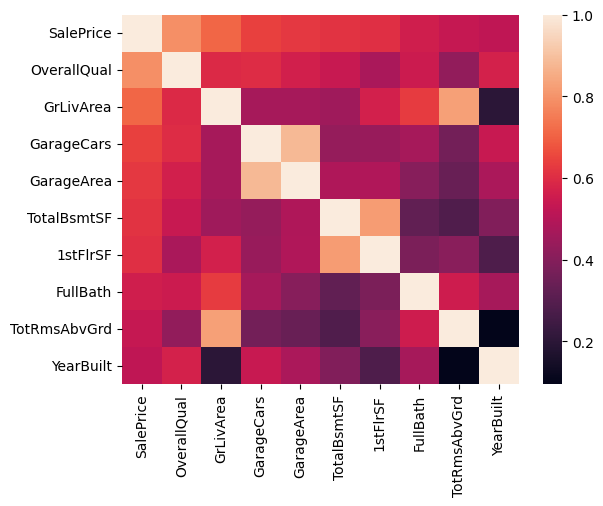

In [10]:
# Correlation Heatmap of top k=10 featurs in the dataset  
numeric_df = data.select_dtypes(include='number')
cor=numeric_df.corr()
k=10
co=cor.nlargest(k,"SalePrice")["SalePrice"].index
cm=np.corrcoef(data[co].values.T)
heat=sns.heatmap(cm,yticklabels=co.values,xticklabels=co.values)
plt.show()


In [11]:
cols=[co.values]
cols

[array(['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars',
        'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'FullBath',
        'TotRmsAbvGrd', 'YearBuilt'], dtype=object)]

Target looks like regression


C:\Users\Nihal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\dabl\plot\utils.py:712: UserWarning: Dropped 2 outliers in column SalePrice.
  warn("Dropped {} outliers in column {}.".format(
C:\Users\Nihal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\dabl\plot\supervised.py:652: UserWarning: Discarding 2 outliers in target column.
  warn(f"Discarding {n_outliers} outliers in target column.",
C:\Users\Nihal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\dabl\plot\supervised.py:214: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  medians = X_new.groupby(col)[target_col].med

[<Axes: title={'center': 'Target distribution'}, xlabel='SalePrice', ylabel='frequency'>,
 array([[<Axes: title={'center': 'F=8.09E-01'}, xlabel='OverallQual (jittered)', ylabel='SalePrice'>,
         <Axes: title={'center': 'F=7.30E-01'}, xlabel='GrLivArea'>,
         <Axes: title={'center': 'F=6.53E-01'}, xlabel='YearBuilt'>,
         <Axes: title={'center': 'F=6.48E-01'}, xlabel='GarageArea'>],
        [<Axes: title={'center': 'F=6.01E-01'}, xlabel='TotalBsmtSF', ylabel='SalePrice'>,
         <Axes: title={'center': 'F=5.74E-01'}, xlabel='1stFlrSF'>,
         <Axes: title={'center': 'F=5.31E-01'}, xlabel='TotRmsAbvGrd (jittered)'>,
         <Axes: >]], dtype=object),
 array([[<Axes: title={'center': 'F=3.60E-01'}, xlabel='SalePrice', ylabel='GarageCars'>,
         <Axes: title={'center': 'F=2.56E-01'}, xlabel='SalePrice', ylabel='FullBath'>]],
       dtype=object)]

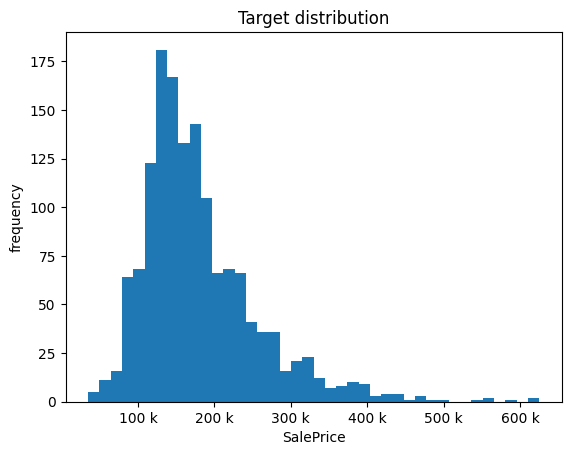

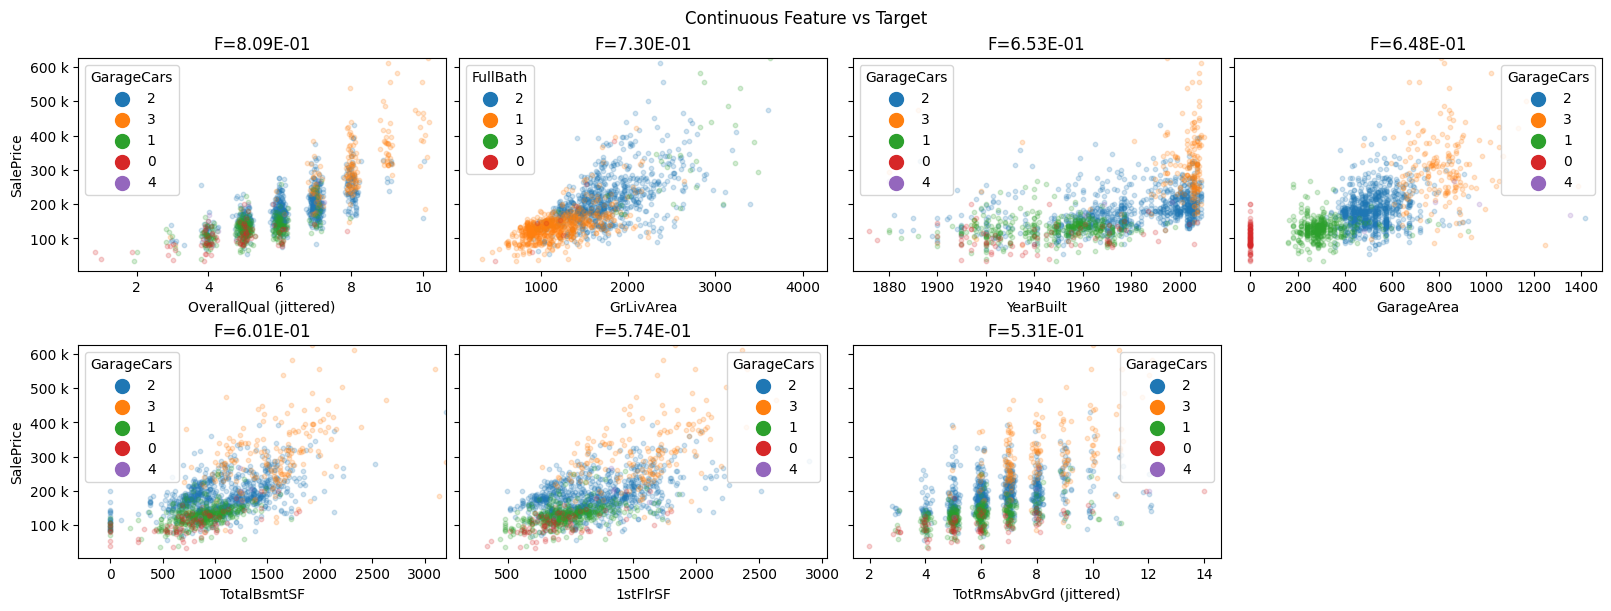

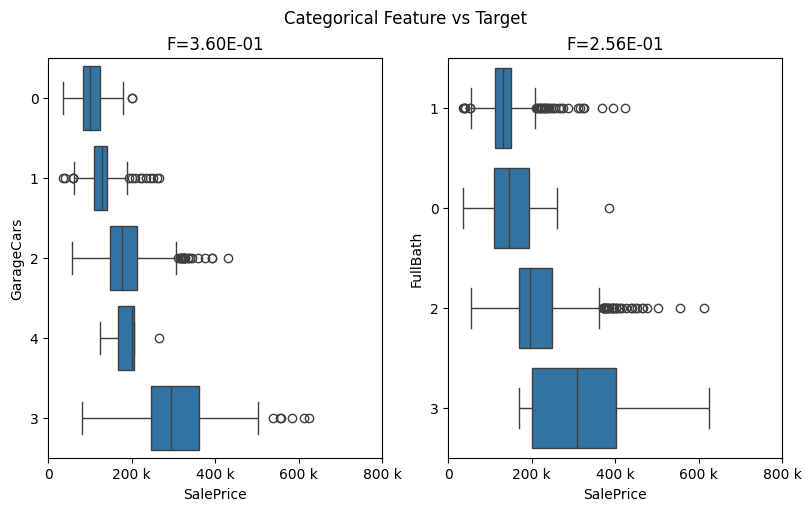

In [12]:
# Ploting the final 10 elements according to target to find out outliers and any other details in featurs 
dbl.plot(data[co],target_col="SalePrice")

In [13]:
df=data[co]

In [14]:
df

,SalePrice,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,FullBath,TotRmsAbvGrd,YearBuilt
0,208500,7,1710,2,548,856,856,2,8,2003
1,181500,6,1262,2,460,1262,1262,2,6,1976
2,223500,7,1786,2,608,920,920,2,6,2001
3,140000,7,1717,3,642,756,961,1,7,1915
4,250000,8,2198,3,836,1145,1145,2,9,2000
...,...,...,...,...,...,...,...,...,...,...
1455,175000,6,1647,2,460,953,953,2,7,1999
1456,210000,6,2073,2,500,1542,2073,2,7,1978
1457,266500,7,2340,1,252,1152,1188,2,9,1941
1458,142125,5,1078,1,240,1078,1078,1,5,1950


## Data Quality Check 

In [15]:
df.isnull().sum()

SalePrice       0
OverallQual     0
GrLivArea       0
GarageCars      0
GarageArea      0
TotalBsmtSF     0
1stFlrSF        0
FullBath        0
TotRmsAbvGrd    0
YearBuilt       0
dtype: int64

In [16]:
df.duplicated().sum()

0

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   SalePrice     1460 non-null   int64
 1   OverallQual   1460 non-null   int64
 2   GrLivArea     1460 non-null   int64
 3   GarageCars    1460 non-null   int64
 4   GarageArea    1460 non-null   int64
 5   TotalBsmtSF   1460 non-null   int64
 6   1stFlrSF      1460 non-null   int64
 7   FullBath      1460 non-null   int64
 8   TotRmsAbvGrd  1460 non-null   int64
 9   YearBuilt     1460 non-null   int64
dtypes: int64(10)
memory usage: 114.2 KB


## Prep for Model training 

In [18]:
#separating data to train and test using model 
x = df.drop(columns="SalePrice")
y=df["SalePrice"]